<a href="https://colab.research.google.com/github/AlexanderLopez2k24/Deep-Learning-/blob/main/Evaluacion1_DeepLearning008V_Alexander_Lopez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EVALUACION 1**

Integrante: Alexander López

Introducción:

- Como bien muchos sabemos, deep learning actualmente es muy importante para el dia a dia, ya que deep learning, se encarga de ejecutar redes neuronales artificiales, que estas mismas se basan en ejecutar procesos completamente dificiles, actualmente hay muchos proyectos grandes que tienen implementado esta rama, uno de ellos es el clasico DLSS de nvidia (Deep learning Super Sampling), como otros proyectos mas que se suelen manejar en deep learning

- MNIST, es un dataset que contiene 70000 imagenes totales, en escala de grises de tamaño (28x28), la cual contiene numeros del 0 al 9 de manera manuscrita, 60000 imagenes se ocupan para prueba y 10000 para testeo del mismo.

- En base a esto, se eligira MNIST para este proyecto, el problema que se busca solucionar dentro del proyecto, es implementar y desarrollar un modelo completo de deep learning en base al dataset MNIST, para optimizar modelos, configuracion de hiperparametros para mejorar precisamente el modelo y tambien permitir identificar varias combinaciones diferentes, para ver cual de ellas es mejor para optimizar y por ultimo verificar a traves de metricas, si el desarrollo ha sido el correcto para cada modelado.


# Carga de datos del modelo

**La siguiente celda del codigo, cargara el dataset de MNIST a nivel de nube, pero primeramente para la carga, tenemos que importar todo lo necesario a ocupar**

In [ ]:
# Se importa TensorFlow/Keras para la carga del dataset de MNIST, desde internet
from tensorflow import keras

# Se importa Numpy para calculos matematicos dentro del modelo, matrices y arreglos
# dentro del modelo
import numpy as np

# Se importa tensorflow individualmente
import tensorflow as tf

# Se importa matplotlib para la visualizacion de imagenes y de metricas.
from matplotlib import pyplot as plt

# Esta importacion, tiene como fin, visualizacion, manipulacion y analisis
# dentro de los datasets
import pandas as pd

# Se utiliza sklearn para la impresion de las metricas a utilizar
from sklearn.metrics import classification_report

**Estas importaciones son muy importantes, ya que sin ellas, directamente el proyecto nisiquiera se podria trabajar o tomar datos del dataset**

In [ ]:
# Para cargar el dataset se ocupara keras, que es parte de tensorflow
# Tambien, se mostraran los datos divididos en entrenamiento y prueba

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape) # Muestra las dimensiones y el numero de datos de entrenamiento
print(x_test.shape) # Muestra las dimensiones del los datos de prueba

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


**El dataset, contiene 60.000 Imagenes de entrenamiento de tamaño (28x28) todos estos, siendo numeros manuscritos y por otra parte**

**Para testeo, contiene 10.000 datos de igual tamaño (28x28), para prueba**

Este apartado es importante, ya que permite verificar que el modelo efectivamente este mostrando todo de manera correcta, tanto la cantidad de imagenes, como el tamaño

# Muestra del dataset / Carga de datos del modelo

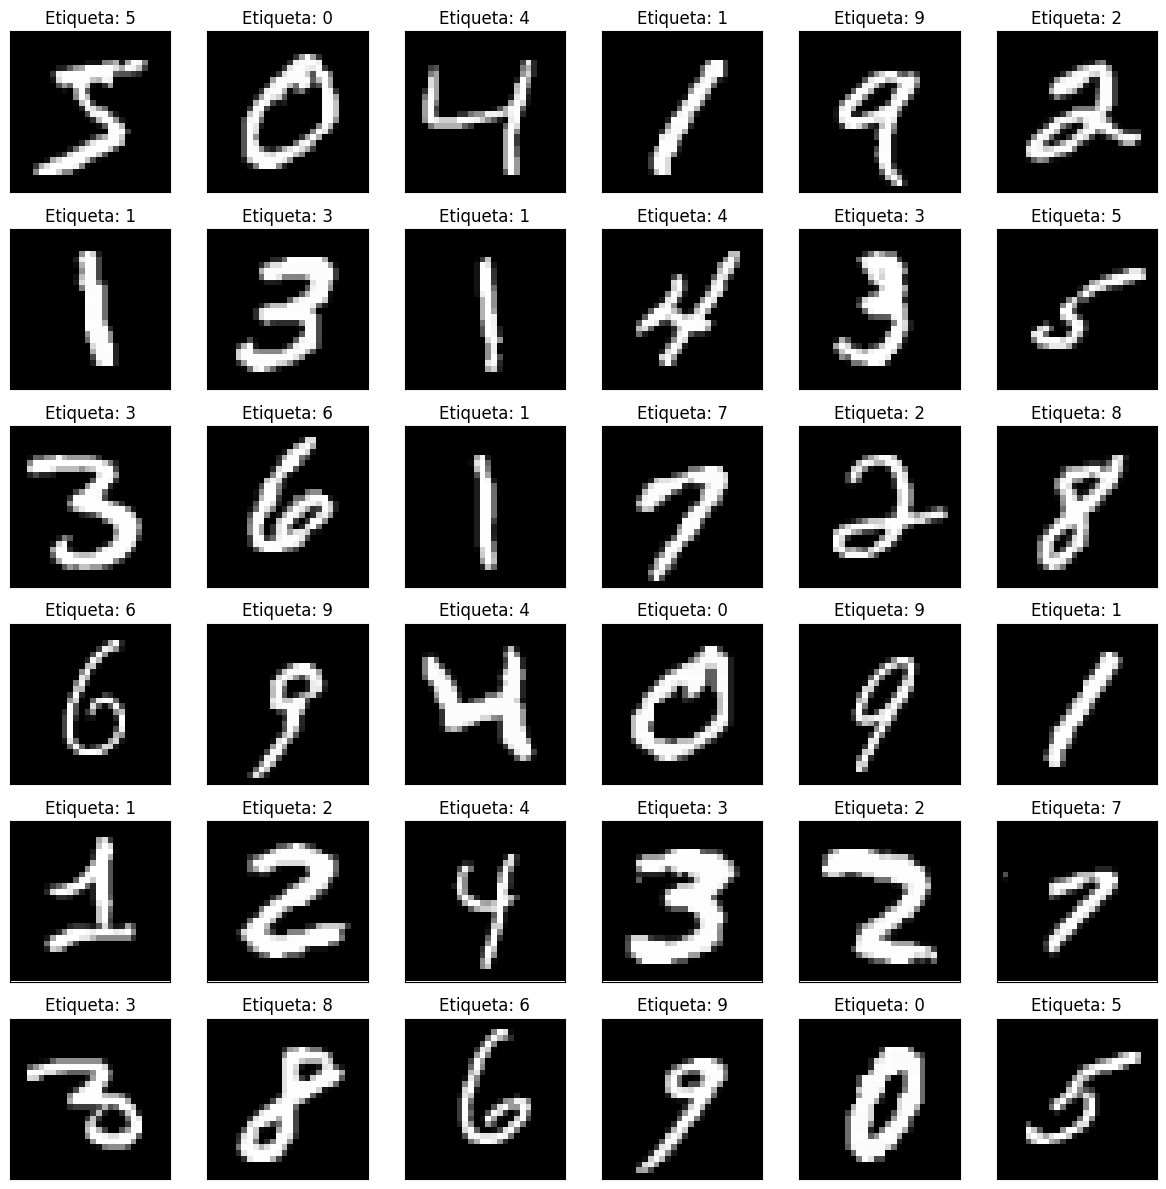

In [ ]:
# Se genera la grilla de tamaño 6x6, para ser visualizada posteriormente
# Para mostrar las etiquetas de los datos y el dato original (Numero)
# y el numero de la etiqueta del dato, para ver y visualizar ejemplos del dataset
h = 6 # filas de grilla
w = 6 # Columnas de grilla

#
fig, axs = plt.subplots(h, w, figsize=(2*h, 2*w))

# Recorrer la etiqueta junto con los datos, para posteriormente ser visualizados
for i in range(h):
    for j in range(w):
        idx = i * w + j

        # Ordenar y limpiar la visualizacion antes de ser mostrada
        axs[i, j].imshow(x_train[idx], cmap='gray')
        axs[i, j].set_title(f"Etiqueta: {y_train[idx]}")
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])

plt.tight_layout()
plt.show() # Muestra las etiquetas del test junto con el numero real, para posteriormente visualizarlas

**Este codigo, se encarga de mostrar los datos reales, junto con sus etiquetas
dentro del dataset real de mnist, para explorar los datos antes de ser entrenados**

# Preprocesamiento de datos

Esta fase permite preprocesar los datos crudos antes de precisamente ser entrenados y utilizados por MLP y las redes neuronales, para procesar datos de manera limpia, ordenada, estructurada y clara.

Normalizacion de datos - Transformacion - Integracion

In [ ]:
# Se transforma la imagen de matriz 28x28 a un vector de 784, para ser utilizado
# dentro de las redes neuronales artificiales y perceptrones multicapa (MLP)
x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)

# Despues de ese apartado, se normalizan los valores para ser entrenados y preparados
# para el modelo y asi obteniendo mayor velocidad y rendimiento a la hora del entrenamiento
# y testeo del modelo
x_train = x_train / 255.0
x_test = x_test / 255.0

# Finalmente, se transforma el valor y a formato one hot encoding
# Para tener 10 componentes categoricos
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

Esta fase del preprocesamiento de datos es importante, ya que permite normalizar los valores y datos, antes de que el modelo sea usado y entrenado para las redes neuronales y perceptrones multicapa

# Parte 2 - Definición de la arquitectura

En este apartado, se define la arquitectura a utilizar, la cual sera de perceptron multicapa (MLP)

Se utiliza esta arquitectura, debido a que MNIST trabaja con datos numericos en imagenes blanco y negro, que van desde al 0 al 9, a comparacion de otros modelos mas complejos como pueden ser cifar10 o fashion-mnist que ya tienen una estructura mas completa o compleja que mnist, aplicar un modelo de perceptron manual, directamente no seria lo mas recomendable, ya que mnist es un dataset que viene preentrenado anteriormente, por lo cual el uso del perceptron directamente no es recomendable


por otra parte, mnist es un problema de clasificacion multiclase.

In [ ]:
# Comenzamos entrenando la red en base a feed fordward
# donde tambien es muy utilizada para mnist (Muy utilizada en mnist)

# Se entrena el primer modelo a utilizar (Sin optimizacion)
# A medida que se ejecuta el codigo, se van utilizando capas ocultas y sus respectivo codigo de activacion y salida
mlp_base_1 = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)), # Se utiliza principalmente la funcion relu, ya que es indicada para problemas de clasificacion multiclase como mnist directamente
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax') # Se utiliza la salida softmax
])

# Se ocupa la compilacion, utilizando primeramente un learning rate de 0.001
# y una perdida categorica, ya que se utiliza one hot encoding
mlp_base_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_base_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

En el recuadro que aparece al final, aparece la cantidad de redes entrenables en base al modelo, junto con los parametros totales que se pueden utilizar junto con sus capas (3 totales) cada una describiendo el tamaño y la dimension que van a ocupar

Fase 3 - Entrenamientos del modelo

In [ ]:
# A continuacion, se entrena el modelo con #.fit, funcion implementada dentro de
# Tensorflow - Keras, para ejecutar el modelo con los respectivos parametros de entrenamiento
# batch_size - epochs

historial_base = mlp_base_1.fit(
    x_train, y_train,
    epochs=50, # Epocas a ocupar, en este caso 50 epocas totales
    batch_size=128, # Tamaño del entrenamiento, en este caso 128, para ejecucion mas rapida del codigo
    validation_split=0.1, # Validacion de cada split en base al entrenamiento 90% Entrenamiento 10% prueba
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9143 - loss: 0.2951 - val_accuracy: 0.9672 - val_loss: 0.1169
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9679 - loss: 0.1057 - val_accuracy: 0.9748 - val_loss: 0.0875
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9785 - loss: 0.0688 - val_accuracy: 0.9783 - val_loss: 0.0773
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9845 - loss: 0.0500 - val_accuracy: 0.9793 - val_loss: 0.0679
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9881 - loss: 0.0367 - val_accuracy: 0.9787 - val_loss: 0.0739
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9902 - loss: 0.0292 - val_accuracy: 0.9787 - val_loss: 0.0782
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9920 - loss: 0.0255 - val_accuracy: 0.9808 - val_loss: 0.0773
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9922 - loss: 0.0235 - val_accuracy

Finalizando la ejecucion del primer modelo base, se ve que el modelo es casi perfecto en cuanto al valor del accuracy, lo cual puede mostrar un overfitting dentro del modelo, para esto, vamos a experimentar con distintos codigos, pero cambiando parametros especificos

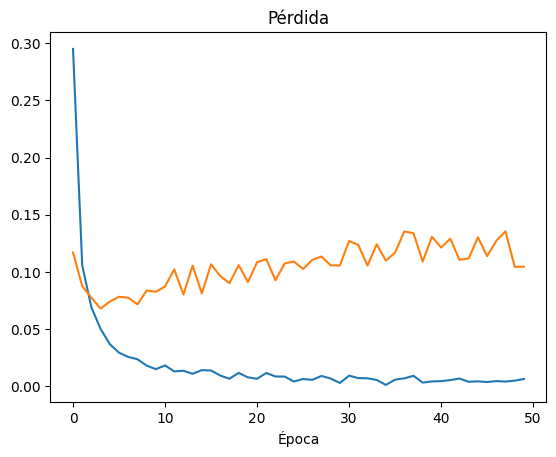

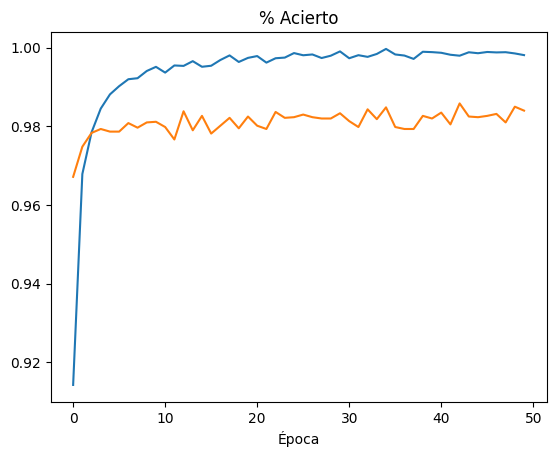

In [ ]:
# A continuacion, se muestra un grafico explicativo de la ejecucion del codigo, validando
# entre el entrenamiento y la validacion, en base a la perdida por epocas
plt.plot(historial_base.history['loss'])
plt.plot(historial_base.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(historial_base.history['accuracy'])
plt.plot(historial_base.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Como se logra ver en el modelo base, la perdida va aumentando de manera gradual a medida que se va ejecutando cada epoca, pero tambien, se muestra un acierto por cada epoca un poco inestable

Experimento 1 - Cambiando Batch size y Epocas - Entrada y salidas

**En este experimento, se probara como experimento cambiar las epocas, tambien se cambiaran los valores de entrada y salida del modelo**

In [ ]:
mlp_base_exp1 = keras.Sequential([
    keras.layers.Dense(256, activation='tanh', input_shape=(784,)), # Para este experimento, se probara a cambiar la activacion a una tahn
    keras.layers.Dense(128, activation='tanh'), # Se sigue utilizando relu en las capas, ya que las otras activaciones son de salida como tahn, sigmoide y
    keras.layers.Dense(64, activation='tanh'),
    keras.layers.Dense(10, activation='softmax') # Se utiliza la salida tanh, como parametro a experimentar
])

# Se ocupa la compilacion, utilizando primeramente un learning rate de 0.001
# y una perdida categorica, ya que se utiliza one hot encoding
mlp_base_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp_base_exp1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Como se puede ver, se ven las distintas capas ocultas, en este caso 3, junto con la de salida, que contienen un total de 242,762 parametros

In [ ]:
# A continuacion, se entrena el modelo con #.fit,

historial_base_exp1 = mlp_base_exp1.fit(
    x_train, y_train,
    epochs=20, # Epocas a ocupar, en este caso 30 epocas totales, viendo que puede afectar al modelo
    batch_size=128, # Tamaño del entrenamiento, en este caso 128, para ejecucion mas rapida del codigo
    validation_split=0.1, # Validacion de cada split en base al entrenamiento 90% Entrenamiento 10% prueba
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8803 - loss: 0.0877 - val_accuracy: 0.9518 - val_loss: 0.0343
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9500 - loss: 0.0325 - val_accuracy: 0.9695 - val_loss: 0.0214
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9670 - loss: 0.0216 - val_accuracy: 0.9727 - val_loss: 0.0178
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9764 - loss: 0.0158 - val_accuracy: 0.9770 - val_loss: 0.0152
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9817 - loss: 0.0121 - val_accuracy: 0.9768 - val_loss: 0.0155
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9864 - loss: 0.0094 - val_accuracy: 0.9782 - val_loss: 0.0133
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9899 - loss: 0.0073 - val_accuracy: 0.9785 - val_loss: 0.0135
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9922 - loss: 0.0059 - val_accu

Cambiando los parametros en este experimento, se noto que al elegir la entrada tanh, se noto un sobreajuste muy claro, siendo que el modelo sale con valores de perdida de mas de 1, por lo cual, esta entrada de salida, directamente no es recomendable para el modelo a optimizar

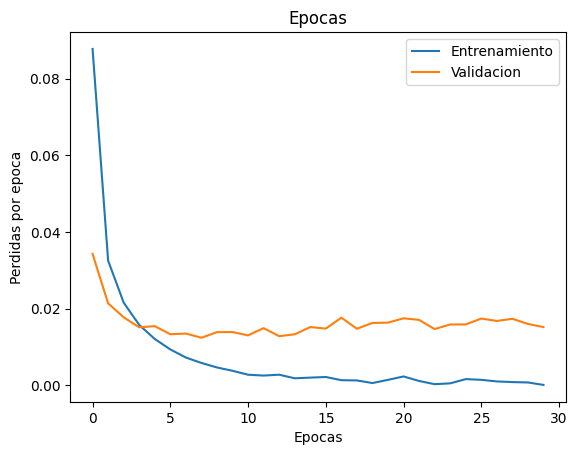

In [ ]:
plt.plot(historial_base_exp1.history['loss'], label='Entrenamiento')
plt.plot(historial_base_exp1.history['val_loss'], label='Validacion')

plt.title('Epocas')
plt.xlabel('Epocas')
plt.ylabel('Perdidas por epoca')
plt.legend()

plt.show()

Como se logra notar en el recuadro de visualizacion, el modelo es establemente correcto, pero esto en la practica es incorrecto, ya que el modelo presenta un sobreajuste demasiado notorio, lo cual es incorrecto, ya que quiere decir que el modelo predice perfectamente cada prediccion

In [ ]:
# En el siguiente recuadro, se comparan en base a ambos modelos, el base y el experimentado, que cambia las funciones de activacion
# Ya que en la segunda, se utiliza tanh en vez de relu, y tambien se baja la cantidad de epocas a 30
# Ambos modelos tienen sobreajuste, pero en el de tanh, se presenta un menor valor

comparacion = pd.DataFrame({
    "Modelo": ["modelo base 1 - Entrenado con 50 epocas)", "modelo experimento 1( modelo con tanh y 30 epocas)"],
    "Accuracy": [historial_base.history["accuracy"][-1],
                 historial_base_exp1.history["accuracy"][-1]],
    "Val Accuracy": [historial_base.history["val_accuracy"][-1],
                     historial_base_exp1.history["val_accuracy"][-1]],
    "Loss": [historial_base.history["loss"][-1],
             historial_base_exp1.history["loss"][-1]]
})

print(comparacion)

                                              Modelo  Accuracy  Val Accuracy  \
0           modelo base 1 - Entrenado con 50 epocas)  0.998111      0.984000   
1  modelo experimento 1( modelo con tanh y 30 epo...  0.999926      0.981167   

       Loss  
0  0.006212  
1  0.000134  


Como se puede notar en ambos modelos, el valor del experimento 1, nota un accuracy o exactitud totalmente perfectos, en la practica no esta bien, ya que claramente el modelo aprendio muy bien de los valores,

**## Experimento controlado 1: cambio de learning rate**

In [ ]:
# Experimento controlado 2: cambio de learning rate a 0,01

# En este segundo experimento, se realiza el cambio de learning rate, para ver que tanto afecta un learning rate
# o tasa de aprendizaje mas baja al proyecto

learning_rates = [0.01]
resultados_lr = []

for lr in learning_rates:
    modelo_lr = keras.Sequential([
        keras.layers.Dense(256, activation='relu', input_shape=(784,)),
        keras.layers.Dense(128, activation='relu'), # Se define la activacion relu
        keras.layers.Dense(64, activation='relu'), # ya que es la mas indicada para trabajos multiclase, como MNIST
        keras.layers.Dense(10, activation='softmax') # Se define la salida softmax, ya que es indicada tambien para tipos de trabajo multiclase, aplicando el descenso del gradiente
    ])

    modelo_lr.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    historial_lr = modelo_lr.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.1
    )

    loss, accuracy = modelo_lr.evaluate(x_test, y_test)

    resultados_lr.append({
        "Learning Rate": lr,
        "Accuracy": accuracy,
        "Loss": loss,
        "Val Accuracy": historial_lr.history["val_accuracy"][-1],
        "Val Loss": historial_lr.history["val_loss"][-1]
    })

tabla_lr = pd.DataFrame(resultados_lr)
tabla_lr

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9195 - loss: 0.2674 - val_accuracy: 0.9537 - val_loss: 0.1583
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9616 - loss: 0.1344 - val_accuracy: 0.9718 - val_loss: 0.1045
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9706 - loss: 0.1043 - val_accuracy: 0.9693 - val_loss: 0.1139
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9734 - loss: 0.0922 - val_accuracy: 0.9707 - val_loss: 0.1039
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9765 - loss: 0.0833 - val_accuracy: 0.9667 - val_loss: 0.1609
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9795 - loss: 0.0745 - val_accuracy: 0.9763 - val_loss: 0.1049
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9814 - loss: 0.0680 - val_accuracy: 0.9768 - val_loss: 0.0978
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9819 - loss: 0.0660 - val_accur

,Learning Rate,Accuracy,Loss,Val Accuracy,Val Loss
0,0.01,0.973,0.154384,0.976333,0.135967


En este caso, al cambiar el learning rate del codigo, se ve claramente un accuracy menos exacto a comparacion del modelo con tanh, esto quiere decir que aprendio bien del modelo, pero al tener un learning rate mas bajo se optimiza la velocidad, como tambien la precision del modelo al aprender

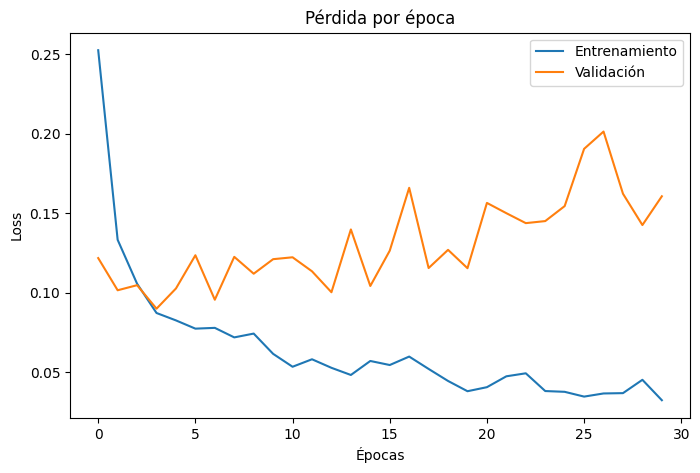

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(historial_lr.history['loss'], label='Entrenamiento')
plt.plot(historial_lr.history['val_loss'], label='Validación')
plt.title('Pérdida por época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

Como se logra ver en la ejecucion, aunque el learning rate sea bajo, el modelo aprende igual, pero no es tan exacto, comparado con experimentos basados en cambio de epocas y de activaciones, como en este caso sucedio con el experimento con tanh, esto, teniendo en cuenta que el modelo aprende de la misma manera, aun teniendo un aprendizaje bajo, pero de manera mas lenta

# Comparacion de activacion y error por modelo

In [ ]:
# =========================
# MÉTRICAS MODELO BASE (ReLU)
# =========================

# En este apartado de codigo, se calculan las metricas del modelo base
# En base a sus predicciones realizadas, para despues generar un reporte del mismo
# Tambien, se ocupa la libreria pandas para su respectivo funcionamiento

y_true = np.argmax(y_test, axis=1)

y_pred_base = mlp_base_1.predict(x_test)
y_pred_base = np.argmax(y_pred_base, axis=1)

reporte_base = classification_report(y_true, y_pred_base, output_dict=True)
df_base = pd.DataFrame(reporte_base).transpose()

# =========================
# MÉTRICAS DEL MODELO TANH
# =========================
y_pred_tanh = mlp_base_exp1.predict(x_test)
y_pred_tanh = np.argmax(y_pred_tanh, axis=1)

reporte_tanh = classification_report(y_true, y_pred_tanh, output_dict=True)
df_tanh = pd.DataFrame(reporte_tanh).transpose()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# Se evaluan ambos modelos, en este caso el base, que contiene la activacion relu
# y el segundo, que contiene la activacion tanh
loss_base, acc_base = mlp_base_1.evaluate(x_test, y_test, verbose=0)
loss_tanh, acc_tanh = mlp_base_exp1.evaluate(x_test, y_test, verbose=0)


# Se ocupa la libreria pandas para ejecutar comparaciones de ambas metricas de ambos modelos
# en este caso, tomando en cuenta el modelo con tanh y el modelo con relu
comparacion_metricas = pd.DataFrame({
    "Modelo": ["ReLU", "tanh"],
    "Loss": [ # Se compara primeramente el valor de perdida de ambos modelos
        loss_base,
        loss_tanh
    ],
    "Accuracy": [ # Se compara como primera metrica, la exactitud del modelo
        acc_base,
        acc_tanh
    ],
    "Precision": [ # Se compara como segunda metrica, la precision
        df_base.loc["macro avg", "precision"],
        df_tanh.loc["macro avg", "precision"]
    ],
    "Recall": [ # Se compara como tercera metrica, la sensibilidad o recall del modelo
        df_base.loc["macro avg", "recall"],
        df_tanh.loc["macro avg", "recall"]
    ],
    "F1-score": [ # Y como ultima metrica, s
        df_base.loc["macro avg", "f1-score"],
        df_tanh.loc["macro avg", "f1-score"]
    ]
})

print(comparacion_metricas)

  Modelo      Loss  Accuracy  Precision    Recall  F1-score
0   ReLU  0.117185    0.9811   0.980995  0.981064  0.981001
1   tanh  0.014723    0.9817   0.981546  0.981515  0.981525


Como se puede ver en la comparacion de ambas metricas de ambos modelos, los valores son muy exactos en cuanto a las primeras metricas, pero en el loss, se logra ver una diferencia muy grande entre ambos modelos comparados, esto siendo que tanh tiene una perdida mas baja que el modelo ReLU

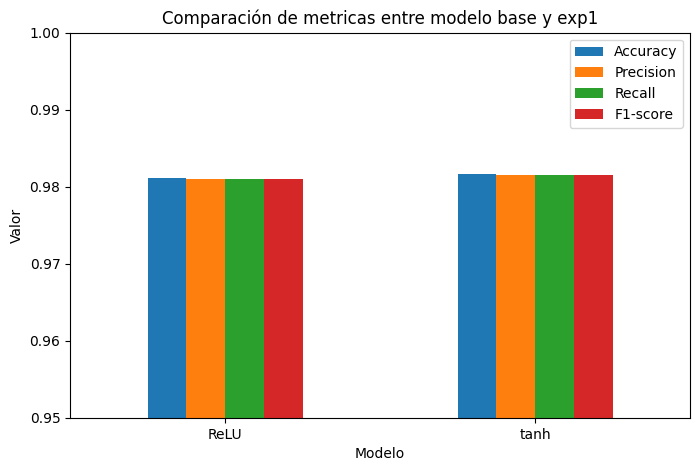

In [ ]:
# En este codigo, se comparan las metricas entre los 2 modelos experimentados anteriormente
# con la libreria de matplotlib
comparacion_metricas.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(8,5)
)

# Se realiza el grafico para mostrar ambas metricas de ambos modelos
# en base a la activacion ocupada, en este caso del modelo base y del modelo experimentados
plt.title("Comparación de metricas entre modelo base y exp1")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.ylim(0.95, 1.0)
plt.show()

En comparacion con ambas activaciones ocupadas, se ve que el modelo de relu y tanh no cambian demasiado sus valores, esto puede verse, debido a que

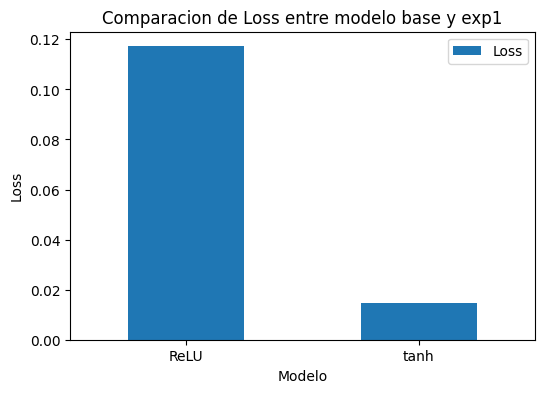

In [ ]:
# En este codigo, se prueba un modelo de barras entre la comparacion de loss
# Ocupando varias variables de salida, en este caso relu y tanh
comparacion_metricas.set_index("Modelo")[["Loss"]].plot(
    kind="bar",
    figsize=(6,4)
)
# Se realiza otro grafico comparativo, para ver los valores de perdida o loss entre ambos modelos
# y activaciones
# en base a la activacion ocupada, en este caso del modelo base y del modelo experimentados
plt.title("Comparacion de Loss entre modelo base y exp1")
plt.ylabel("Loss")
plt.xticks(rotation=0)
plt.show()

En el codigo de comparacion de ambas metricas, se puede ver que el modelo base presenta un mayor valor de perdida que el tanh, esto tomando en cuenta que el valor de activacion relu, es el mas efectivo para este tipo de tecnicas

En base a los ajustes realizados, se verifica que el modelo principal es mas factible dentro de todo, ya que evaluando los distintos modelos hechos anteriormente, se nota claramente que el modelo con tahn y cambiando de epocas, tiene mucho sobreajuste, a comparacion del modelo con relu, que directamente tenia un sobreajuste, pero no tan notorio, por esta razon, se justifica ocupar el modelo base, ya que es el mas exacto, junto con el valor de lr de 0.001 y un batch de 128, un batch menor, haria que el modelo se demorara mucho mas en ejecutar, pero seria mas preciso y por ultimo el tamaño de epocas en 50, ya que son suficientes

# Optimizacion de modelo con Tecnicas - DropOut

En este codigo, se probara a ocupar tecnicas de optimizacion dentro del modelo a utilizar, en este caso el primer modelo base que se utilizo, este mismo lo adaptaremos, pero con la diferencia, de que este mismo, sera optimizado con tecnicas muy ocupadas dentro del deep learning - Como DropOut - Regularizacion del batch y muchas mas

In [ ]:
# En el siguiente comando, se aplica el codigo optimizado, aplicando tecnicas de optimizacion
# Como DropOut, Una de las mas usadas para evitar un sobreajuste notorio en modelos

# Se define el modelo a utilizar, en este caso siempre sera un feed fordward
# Definiendo el modelo base que teniamos, pero aplicandole un dropout de (0.3)
# En todas las capas ocultas del modelo (Entrada)
# Para evitar el sobreajuste dentro del modelo
mlp_opt = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)), # Se utiliza principalmente la funcion relu, ya que es indicada para problemas de clasificacion multiclase como mnist directamente
    keras.layers.Dropout(0.3),
    keras.layers.BatchNormalization(), # Se aplica batch Normalization para entrenar el modelo de manera mucho mas rapida y estable
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.BatchNormalization(), # Se aplica batch Normalization para entrenar el modelo de manera mucho mas rapida y estable
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.BatchNormalization(), # Se aplica batch Normalization para entrenar el modelo de manera mucho mas rapida y estable
    keras.layers.Dense(10, activation='softmax') # Se utiliza la salida softmax
])
# Dentro del compile, tambien se utiliza el optimizador de adam, uno de los mas estandares y efectivos para modelos multiclase como MNIST
mlp_opt.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy', # Se sigue con la perdida categorica, ya que el modelo trabaja con imagenes numericas del (0,9), categoricas
    metrics=['accuracy']
)


mlp_opt.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

Como se logra ver, los parametros de entrada, en base al batch_normalization, se ve menos

In [ ]:
historial_base_opt = mlp_opt.fit(
    x_train, y_train,
    epochs=50, # Se elige para el procesamiento 50 epocas, ya que es un buen tamaño de epocas, para un tamaño de batch, tan alto como es 128
    batch_size=128, # Se elige un batch size de 128, para una ejecucion mucho mas rapido de cada epoca
    validation_split=0.1, # Validacion de cada split en base al entrenamiento 90% Entrenamiento 10% prueba
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8377 - loss: 0.5454 - val_accuracy: 0.9620 - val_loss: 0.1316
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9325 - loss: 0.2359 - val_accuracy: 0.9723 - val_loss: 0.0980
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9482 - loss: 0.1826 - val_accuracy: 0.9698 - val_loss: 0.0972
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9553 - loss: 0.1561 - val_accuracy: 0.9727 - val_loss: 0.0857
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9593 - loss: 0.1392 - val_accuracy: 0.9775 - val_loss: 0.0743
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9654 - loss: 0.1206 - val_accuracy: 0.9768 - val_loss: 0.0741
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9672 - loss: 0.1118 - val_accuracy: 0.9805 - val_loss: 0.0704
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9700 - loss: 0.1050 - val_acc

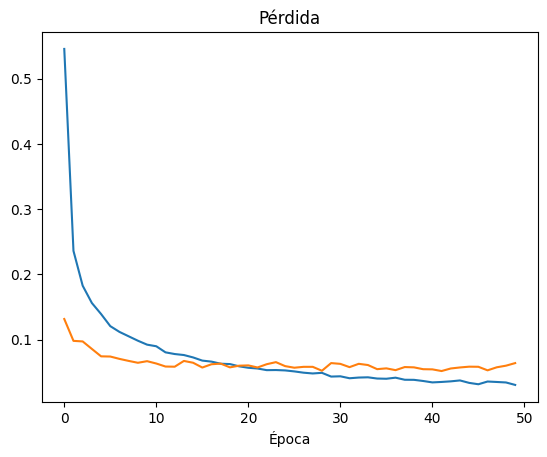

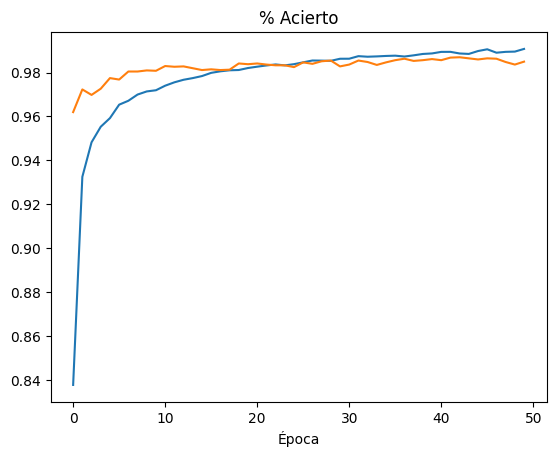

In [ ]:
plt.plot(historial_base_opt.history['loss'])
plt.plot(historial_base_opt.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(historial_base_opt.history['accuracy'])
plt.plot(historial_base_opt.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Como se puede ver en el grafico, a comparacion con los modelos base, en el optimizado, se logra ver un modelo totalmente mas estable en comparacion con los otros modelos que se presentaban anteriormente, como el base con relu o el experimentado con tanh, eso fue a que gracias a los optimizadores, se logro estabilizar el modelo en general entre acierto y perdida por epoca

# Comparacion de modelo base vs optimizado y comparacion de metricas